## Ejercicio 3: Inspección visual de un producto

### Ficha PEAS

| Componente PEAS | Descripción |
| :--- | :--- |
| **Percepción (S)** | Matriz binaria 5x5 de NumPy de la captura (0 = píxel normal, 1 = píxel defectuoso). |
| **Acciones (A)** | Emitir la decisión: "aprobar", "revision manual" o "rechazar", detallando el motivo. |
| **Entorno (E)** | Cinta transportadora en línea de ensamblaje con sistema óptico de visión artificial. |
| **Objetivo** | Garantizar la calidad del producto en la línea de producción minimizando mermas. |
| **Medida de desempeño (P)** | Precisión en detección de componentes defectuosos y baja tasa de falsos rechazos. |

### Justificación de las reglas

Un producto sin ningún píxel defectuoso (0 defectos) se aprueba de inmediato para acelerar la cadena de empaque. Si se detectan entre 1 y 3 píxeles defectuosos, se deriva a revisión manual puesto que son imperfecciones menores que pueden ser corregidas por un operador sin desechar el producto. Si la pieza presenta más de 3 píxeles defectuosos, se clasifica como falla estructural grave irreparable y se rechaza para evitar distribuir productos defectuosos.

### Código

In [1]:
import numpy as np

def agente_inspeccion(imagen):
    """
    Percepción (S): matriz 5x5 de NumPy (0 = normal, 1 = defectuoso).
    Retorna una tupla: (accion, motivo).
    """
    defectos = np.sum(imagen == 1)
    
    if defectos == 0:
        return "aprobar", "producto en perfecto estado sin defectos detectados"
    elif defectos <= 3:
        return "revision manual", f"se detectaron {defectos} pixeles defectuosos"
    else:
        return "rechazar", f"se detectaron {defectos} pixeles defectuosos"

### Simulación y pruebas

=== PRUEBAS DEL AGENTE DE INSPECCIÓN VISUAL ===
[0 Defectos (Aprobar)] => Decision: APROBAR | Motivo: producto en perfecto estado sin defectos detectados
[1 Defecto (Revisión)] => Decision: REVISION MANUAL | Motivo: se detectaron 1 pixeles defectuosos
[3 Defectos - Caso Borde] => Decision: REVISION MANUAL | Motivo: se detectaron 3 pixeles defectuosos
[5 Defectos (Rechazar)] => Decision: RECHAZAR | Motivo: se detectaron 5 pixeles defectuosos


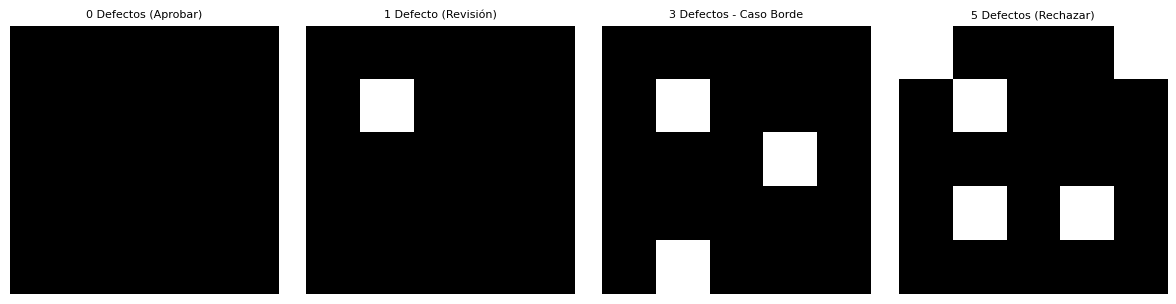

In [2]:
import matplotlib.pyplot as plt

img_0_defectos = np.zeros((5, 5), dtype=int)

img_1_defecto = np.array([
    [0, 0, 0, 0, 0],
    [0, 1, 0, 0, 0],
    [0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0]
])

img_3_defectos_borde = np.array([
    [0, 0, 0, 0, 0],
    [0, 1, 0, 0, 0],
    [0, 0, 0, 1, 0],
    [0, 0, 0, 0, 0],
    [0, 1, 0, 0, 0]
])

img_5_defectos = np.array([
    [1, 0, 0, 0, 1],
    [0, 1, 0, 0, 0],
    [0, 0, 0, 0, 0],
    [0, 1, 0, 1, 0],
    [0, 0, 0, 0, 0]
])

matrices_prueba = [
    ("0 Defectos (Aprobar)", img_0_defectos),
    ("1 Defecto (Revisión)", img_1_defecto),
    ("3 Defectos - Caso Borde", img_3_defectos_borde),
    ("5 Defectos (Rechazar)", img_5_defectos)
]

print("=== PRUEBAS DEL AGENTE DE INSPECCIÓN VISUAL ===")
for nombre, img in matrices_prueba:
    accion, motivo = agente_inspeccion(img)
    print(f"[{nombre}] => Decision: {accion.upper()} | Motivo: {motivo}")

# Visualización con imshow
fig, axes = plt.subplots(1, 4, figsize=(12, 3))
for ax, (nombre, img) in zip(axes, matrices_prueba):
    ax.imshow(img, cmap="gray")
    ax.set_title(nombre, fontsize=8)
    ax.axis('off')

plt.tight_layout()
plt.show()